## Imports et données

In [19]:
import numpy as np                      
import pandas as pd                     
import matplotlib.pyplot as plt         
import matplotlib.patches as mpatches 


donnees = [
    [1881.9,  96.8, 14.2, 25.2, 1135.5, 278.3],
    [3369.8,  96.8, 10.8, 51.6, 1331.7, 284.0],
    [4467.4, 138.2,  9.5, 34.2, 2346.1, 312.3],
    [1862.1,  83.2,  8.8, 27.6,  972.6, 203.4],
    [3499.8, 287.0, 11.5, 49.4, 2139.4, 358.0],
    [3903.2, 170.7,  6.3, 42.0, 1935.2, 292.9],
    [2620.7, 129.5,  4.2, 16.8, 1346.0, 131.8],
    [3678.4, 157.0,  6.0, 24.9, 1682.6, 194.2],
    [3840.5, 187.9, 10.2, 39.6, 1859.9, 449.1],
    [2170.2, 140.5, 11.7, 31.1, 1351.1, 256.5],
    [3920.4, 128.0,  7.2, 25.5, 1911.5,  64.1],
    [2599.6,  39.6,  5.5, 19.4, 1050.8, 172.5],
    [2828.5, 211.3,  9.9, 21.8, 1085.0, 209.0],
    [2498.7, 123.2,  7.4, 26.5, 1086.2, 153.5],
    [2685.1,  41.2,  2.3, 10.6,  812.5,  89.8],
    [2739.3, 100.7,  6.6, 22.0, 1270.4, 180.5],
    [1662.1,  81.1, 10.1, 19.1,  872.2, 123.3],
    [2469.9, 142.9, 15.5, 30.9, 1165.5, 335.5],
    [2350.7,  38.7,  2.4, 13.5, 1253.1, 170.0],
    [3177.7, 292.1,  8.0, 34.8, 1400.0, 358.9],
]

noms_villes = [f"V{i}" for i in range(1, 21)]          
noms_sports = ["H.Ball", "B.Ball", "Tennis", "Gym", "Natation", "F.Ball"]
couleurs_sports = ["steelblue", "darkorange", "forestgreen", "purple", "crimson", "saddlebrown"]

X = np.array(donnees)    
m, p = X.shape           

print(f"Dimensions de X : {m} individus × {p} variables")
pd.DataFrame(X, index=noms_villes, columns=noms_sports)

Dimensions de X : 20 individus × 6 variables


,H.Ball,B.Ball,Tennis,Gym,Natation,F.Ball
V1,1881.9,96.8,14.2,25.2,1135.5,278.3
V2,3369.8,96.8,10.8,51.6,1331.7,284.0
V3,4467.4,138.2,9.5,34.2,2346.1,312.3
V4,1862.1,83.2,8.8,27.6,972.6,203.4
V5,3499.8,287.0,11.5,49.4,2139.4,358.0
V6,3903.2,170.7,6.3,42.0,1935.2,292.9
V7,2620.7,129.5,4.2,16.8,1346.0,131.8
V8,3678.4,157.0,6.0,24.9,1682.6,194.2
V9,3840.5,187.9,10.2,39.6,1859.9,449.1
V10,2170.2,140.5,11.7,31.1,1351.1,256.5


## Centrage & Réduction

In [5]:
moyenne = np.mean(X, axis=0)      
Y = X - moyenne                   

sigma = np.std(X, axis=0, ddof=0)  
Z = Y / sigma                      


R = (1/m) * (Z.T @ Z)              

print("Matrice de corrélation R :")
pd.DataFrame(np.round(R, 4), index=noms_sports, columns=noms_sports)

Matrice de corrélation R :


,H.Ball,B.Ball,Tennis,Gym,Natation,F.Ball
H.Ball,1.0000,0.4518,-0.1059,0.5173,0.8651,0.3525
B.Ball,0.4518,1.0000,0.3535,0.5904,0.5300,0.6192
Tennis,-0.1059,0.3535,1.0000,0.5344,0.1010,0.5859
Gym,0.5173,0.5904,0.5344,1.0000,0.5977,0.7501
Natation,0.8651,0.5300,0.1010,0.5977,1.0000,0.4680
F.Ball,0.3525,0.6192,0.5859,0.7501,0.4680,1.0000


##  Valeurs propres & Vecteurs propres de R

In [6]:

valeurs_propres, vecteurs_propres = np.linalg.eigh(R)
ordre = np.argsort(valeurs_propres)[::-1]
valeurs_propres  = valeurs_propres[ordre]        
vecteurs_propres = vecteurs_propres[:, ordre]     


inertie_totale = np.sum(valeurs_propres)


taux        = valeurs_propres / inertie_totale * 100  
taux_cumule = np.cumsum(taux)                          

df_vp = pd.DataFrame({
    "Valeur propre"   : np.round(valeurs_propres, 4),
    "Taux (%)"        : np.round(taux, 2),
    "Taux cumulé (%)" : np.round(taux_cumule, 2)
}, index=[f"Axe {i+1}" for i in range(p)])

print("Valeurs propres de R :")
print(df_vp.to_string())
print(f"\nInertie totale = {inertie_totale:.4f}  (doit être égale à p = {p})")

Valeurs propres de R :
       Valeur propre  Taux (%)  Taux cumulé (%)
Axe 1         3.4859     58.10            58.10
Axe 2         1.4219     23.70            81.80
Axe 3         0.4728      7.88            89.68
Axe 4         0.2943      4.91            94.58
Axe 5         0.2187      3.64            98.23
Axe 6         0.1064      1.77           100.00

Inertie totale = 6.0000  (doit être égale à p = 6)


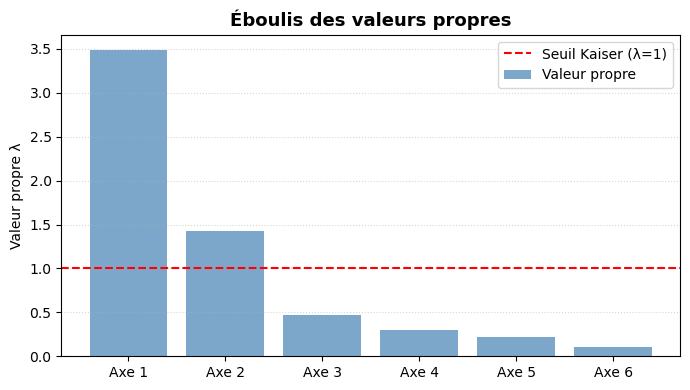

→ On retient les axes dont la valeur propre > 1 (critère de Kaiser).
→ Nombre d'axes retenus : 2


In [7]:

fig, ax = plt.subplots(figsize=(7, 4))
axes_labels = [f"Axe {i+1}" for i in range(p)]

ax.bar(axes_labels, valeurs_propres, color="steelblue", alpha=0.7, label="Valeur propre")
ax.axhline(y=1, color="red", linestyle="--", label="Seuil Kaiser (λ=1)")


ax.set_title("Éboulis des valeurs propres", fontsize=13, fontweight="bold")
ax.set_ylabel("Valeur propre λ")
ax.legend()
ax.grid(axis="y", linestyle=":", alpha=0.5)
plt.tight_layout()
plt.show()

print("→ On retient les axes dont la valeur propre > 1 (critère de Kaiser).")
nb_axes = np.sum(valeurs_propres > 1)
print(f"→ Nombre d'axes retenus : {nb_axes}")

# PARTIE A :

### 1 – Coordonnées des individus sur les axes factoriels

In [8]:
C = Z @ vecteurs_propres    

cols_axes = [f"Axe {i+1}" for i in range(p)]
df_C = pd.DataFrame(np.round(C, 4), index=noms_villes, columns=cols_axes)

print("Coordonnées des individus sur les axes factoriels :")
df_C

Coordonnées des individus sur les axes factoriels :


,Axe 1,Axe 2,Axe 3,Axe 4,Axe 5,Axe 6
V1,0.4742,-2.1729,0.4913,-0.3669,0.5693,-0.1313
V2,-1.3744,-0.6095,1.3837,0.5773,-1.1996,0.3793
V3,-2.4612,1.5247,1.0055,-0.4130,0.8020,0.0445
V4,1.3882,-1.1268,0.2195,0.2998,-0.3302,-0.3165
V5,-3.7137,-0.1744,-0.6112,-0.2660,-0.4255,-0.5988
V6,-1.9687,1.2603,0.2360,0.4810,-0.3723,-0.1887
V7,1.5096,0.9687,-0.6866,-0.1040,0.0481,-0.3336
V8,-0.2987,1.4191,-0.2688,-0.2529,0.1277,0.1774
V9,-2.8721,-0.0333,0.2172,0.8031,0.7287,0.1905
V10,-0.1183,-1.3203,0.0718,-0.2553,0.0014,-0.4327


### 2 – Carré de la distance de chaque individu au centre du nuage

In [9]:
d2 = np.sum(C**2, axis=1)   

df_d2 = pd.DataFrame({
    "d²(i, G)" : np.round(d2, 4)
}, index=noms_villes)

print("Carré de la distance de chaque individu au centre du nuage :")
print(df_d2.to_string())

Carré de la distance de chaque individu au centre du nuage :
     d²(i, G)
V1     5.6638
V2     6.0914
V3    10.2089
V4     3.5439
V5    14.8058
V6     5.9255
V7     3.8130
V8     2.2870
V9     9.5092
V10    2.0147
V11    6.2549
V12    4.4793
V13    2.4137
V14    1.5973
V15   11.7368
V16    1.2618
V17    6.9762
V18    6.1155
V19    7.9009
V20    7.4003


### 3 – Somme des distances & déduction

In [10]:

somme_d2 = np.sum(d2)                 
inertie_verif = somme_d2 / m           

print(f"Somme des d²(i,G)    = {somme_d2:.4f}")
print(f"(1/m) × Somme        = {inertie_verif:.4f}")
print(f"Inertie totale (Σλ)  = {inertie_totale:.4f}")
print()
print("✔ Déduction : (1/m)·Σ d²(i,G) = Σ λk = p")
print("  L'inertie totale du nuage est bien conservée par l'ACP.")
print("  Plus d²(i,G) est grand, plus la ville est atypique/éloignée du centre.")

Somme des d²(i,G)    = 120.0000
(1/m) × Somme        = 6.0000
Inertie totale (Σλ)  = 6.0000

✔ Déduction : (1/m)·Σ d²(i,G) = Σ λk = p
  L'inertie totale du nuage est bien conservée par l'ACP.
  Plus d²(i,G) est grand, plus la ville est atypique/éloignée du centre.


Interprétation typique (à adapter à tes résultats exacts) :

Plus la somme des D  est proche de la somme totale des D
​(tous axes), plus le sous-espace choisi représente bien le nuage des individus.

Les individus avec grande distance au centre dans le plan (gros D ) sont des villes “atypiques”, avec des profils de sports très différents de la moyenne

### 4 – Qualité de représentation des individus (cos²)

In [11]:
cos2 = C**2 / d2[:, np.newaxis]    
df_cos2 = pd.DataFrame(
    np.round(cos2[:, :3], 4),
    index=noms_villes,
    columns=["cos²(Axe1)", "cos²(Axe2)", "cos²(Axe3)"]
)

print("Qualité de représentation des individus (cos²) :")
print(df_cos2.to_string())
print()
print("Vérification : somme des cos² sur tous les axes = 1 pour chaque individu")
print(np.round(np.sum(cos2, axis=1), 6))   

Qualité de représentation des individus (cos²) :
     cos²(Axe1)  cos²(Axe2)  cos²(Axe3)
V1       0.0397      0.8336      0.0426
V2       0.3101      0.0610      0.3143
V3       0.5933      0.2277      0.0990
V4       0.5437      0.3583      0.0136
V5       0.9315      0.0021      0.0252
V6       0.6541      0.2681      0.0094
V7       0.5976      0.2461      0.1236
V8       0.0390      0.8805      0.0316
V9       0.8674      0.0001      0.0050
V10      0.0069      0.8652      0.0026
V11      0.0000      0.6274      0.0212
V12      0.8660      0.0240      0.0522
V13      0.0104      0.1275      0.6098
V14      0.7552      0.0156      0.0350
V15      0.8560      0.1055      0.0015
V16      0.9043      0.0908      0.0000
V17      0.7156      0.2326      0.0000
V18      0.0889      0.8153      0.0163
V19      0.7318      0.1298      0.0022
V20      0.5009      0.0113      0.4305

Vérification : somme des cos² sur tous les axes = 1 pour chaque individu
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 

Interprétation :

Si pour une ville, cos est sur l’axe 1 est proche de 1, elle est très bien représentée sur l’axe 1.

Les individus “mal représentés” sur un axe ont un cos² faible sur cet axe.

### 5 – Contribution des individus à l'inertie de chaque axe

In [13]:

CTR = (C**2) / (m * valeurs_propres[np.newaxis, :])  

df_CTR = pd.DataFrame(
    np.round(CTR[:, :3] * 100, 2),   
    index=noms_villes,
    columns=["CTR Axe1 (%)", "CTR Axe2 (%)", "CTR Axe3 (%)"]
)

print("Contribution des individus à l'inertie de chaque axe (en %) :")
print(df_CTR.to_string())
print()
print("Vérification : somme des CTR par axe = 100 %")
print(np.round(CTR[:, :3].sum(axis=0) * 100, 2))

Contribution des individus à l'inertie de chaque axe (en %) :
     CTR Axe1 (%)  CTR Axe2 (%)  CTR Axe3 (%)
V1           0.32         16.60          2.55
V2           2.71          1.31         20.25
V3           8.69          8.17         10.69
V4           2.76          4.46          0.51
V5          19.78          0.11          3.95
V6           5.56          5.59          0.59
V7           3.27          3.30          4.99
V8           0.13          7.08          0.76
V9          11.83          0.00          0.50
V10          0.02          6.13          0.05
V11          0.00         13.80          1.40
V12          5.56          0.38          2.47
V13          0.04          1.08         15.57
V14          1.73          0.09          0.59
V15         14.41          4.35          0.19
V16          1.64          0.40          0.00
V17          7.16          5.71          0.00
V18          0.78         17.53          1.05
V19          8.29          3.61          0.18
V20          5.32 

Les individus qui ont une forte contribution sur un axe sont ceux qui “participent le plus” à la construction de cet axe
 (ils sont les plus extrêmes sur cet axe)


### 6 – Interprétation & individus mal représentés

In [15]:
seuil = 0.5
cos2_plan = cos2[:, 0] + cos2[:, 1]  

print("Qualité de représentation dans le PLAN FACTORIEL (cos²_axe1 + cos²_axe2) :")
df_plan = pd.DataFrame({
    "cos²(plan)"     : np.round(cos2_plan, 4),
    "Bien représenté": ["✔" if v >= seuil else "✘" for v in cos2_plan]
}, index=noms_villes)
print(df_plan.to_string())

print()

print("Individus mal représentés et leur position (signe) sur chaque axe :")
mal_rep = [v for v, q in zip(noms_villes, cos2_plan) if q < seuil]
for ville in mal_rep:
    i = noms_villes.index(ville)
    signe1 = "+" if C[i, 0] >= 0 else "-"
    signe2 = "+" if C[i, 1] >= 0 else "-"
    print(f"  {ville} → cos²={cos2_plan[i]:.3f}  |  Axe1: {signe1}  Axe2: {signe2}")

Qualité de représentation dans le PLAN FACTORIEL (cos²_axe1 + cos²_axe2) :
     cos²(plan) Bien représenté
V1       0.8733               ✔
V2       0.3711               ✘
V3       0.8210               ✔
V4       0.9020               ✔
V5       0.9335               ✔
V6       0.9222               ✔
V7       0.8437               ✔
V8       0.9195               ✔
V9       0.8676               ✔
V10      0.8722               ✔
V11      0.6274               ✔
V12      0.8900               ✔
V13      0.1379               ✘
V14      0.7709               ✔
V15      0.9615               ✔
V16      0.9951               ✔
V17      0.9481               ✔
V18      0.9042               ✔
V19      0.8616               ✔
V20      0.5122               ✔

Individus mal représentés et leur position (signe) sur chaque axe :
  V2 → cos²=0.371  |  Axe1: -  Axe2: -
  V13 → cos²=0.138  |  Axe1: +  Axe2: -


Pour chaque axe, les individus listés ont un cos² < seuil → leur projection sur cet axe n’est pas fiable 

### 7 – Graphe des individus dans le plan factoriel

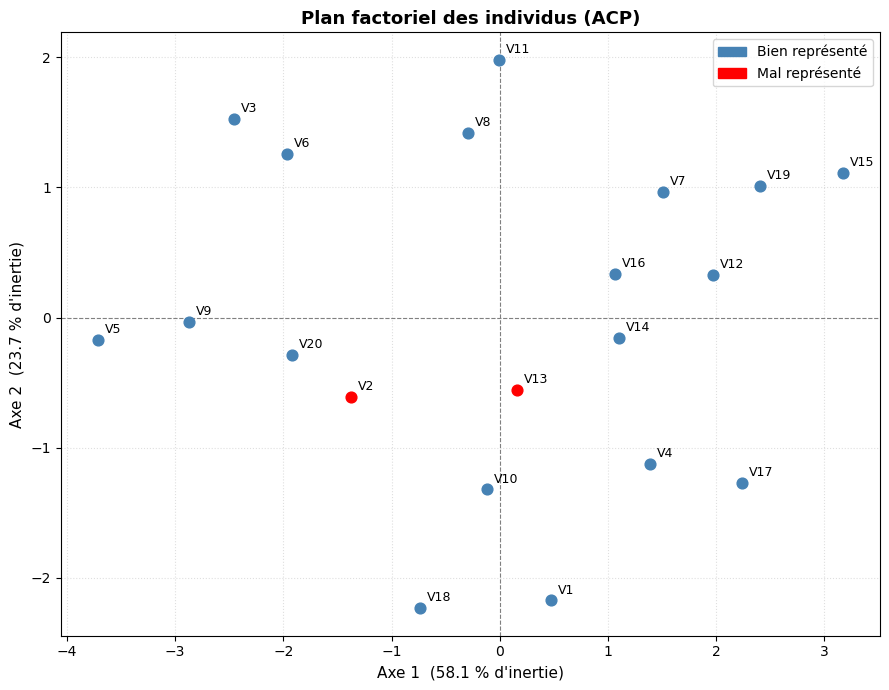

In [16]:

fig, ax = plt.subplots(figsize=(9, 7))

ax.axhline(0, color="gray", linewidth=0.8, linestyle="--")   
ax.axvline(0, color="gray", linewidth=0.8, linestyle="--")  

# Tracé de chaque ville
for i, ville in enumerate(noms_villes):
    couleur = "red" if cos2_plan[i] < seuil else "steelblue"  # rouge = mal représenté
    ax.scatter(C[i, 0], C[i, 1], color=couleur, s=60, zorder=5)
    ax.annotate(ville, (C[i, 0], C[i, 1]),
                textcoords="offset points", xytext=(5, 5), fontsize=9)

# Légende manuelle
patch_bien = mpatches.Patch(color="steelblue", label="Bien représenté")
patch_mal  = mpatches.Patch(color="red",       label="Mal représenté")
ax.legend(handles=[patch_bien, patch_mal])

ax.set_xlabel(f"Axe 1  ({taux[0]:.1f} % d'inertie)", fontsize=11)
ax.set_ylabel(f"Axe 2  ({taux[1]:.1f} % d'inertie)", fontsize=11)
ax.set_title("Plan factoriel des individus (ACP)", fontsize=13, fontweight="bold")
ax.grid(linestyle=":", alpha=0.4)
plt.tight_layout()
plt.show()

---
# PARTIE B

### 1 – Coordonnées des variables sur tous les axes principaux

In [17]:
coord_var = vecteurs_propres * np.sqrt(valeurs_propres[np.newaxis, :])  

df_coord_var = pd.DataFrame(
    np.round(coord_var[:, :3], 4),
    index=noms_sports,
    columns=["Coord Axe1", "Coord Axe2", "Coord Axe3"]
)

print("Coordonnées (corrélations) des variables sur les axes factoriels :")
df_coord_var

Coordonnées (corrélations) des variables sur les axes factoriels :


,Coord Axe1,Coord Axe2,Coord Axe3
H.Ball,-0.7033,0.6597,0.1159
B.Ball,-0.7876,-0.0538,-0.6021
Tennis,-0.5010,-0.7737,0.1847
Gym,-0.8851,-0.1609,0.2072
Natation,-0.8025,0.4912,0.1405
F.Ball,-0.8322,-0.3434,0.0048


### 2 – Cercles de corrélation (plan Axe1×Axe2 et plan Axe1×Axe3)

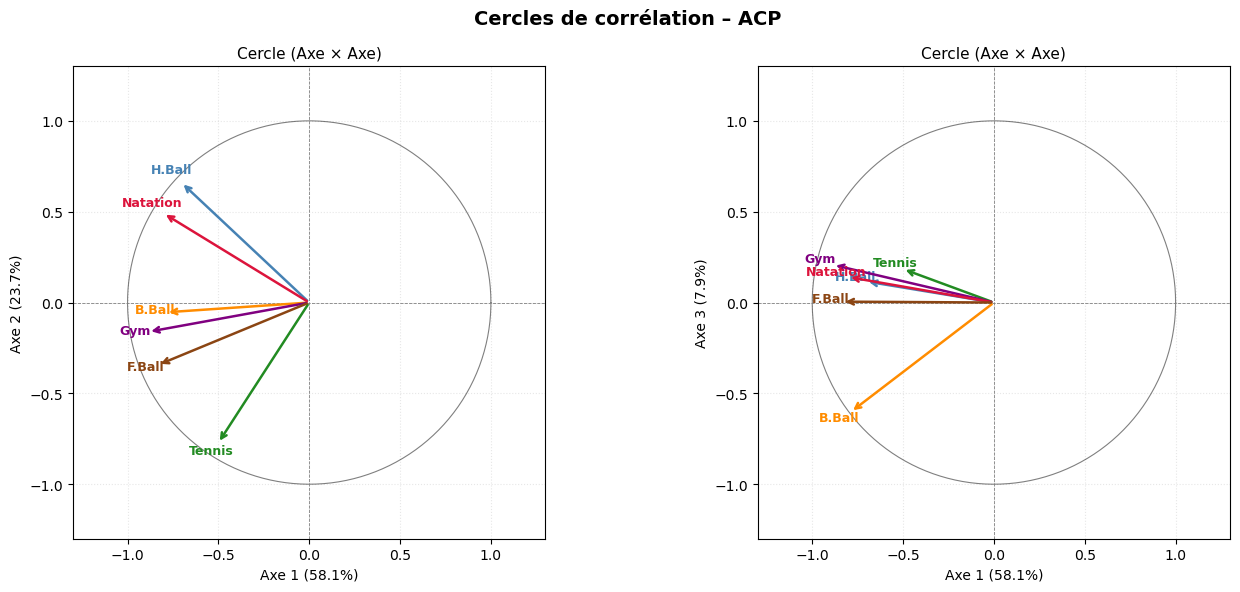

In [20]:
# Deux cercles de corrélation côte à côte : (Axe1, Axe2) et (Axe1, Axe3)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Cercles de corrélation – ACP", fontsize=14, fontweight="bold")

plans = [
    (0, 1, f"Axe 1 ({taux[0]:.1f}%)", f"Axe 2 ({taux[1]:.1f}%)"),
    (0, 2, f"Axe 1 ({taux[0]:.1f}%)", f"Axe 3 ({taux[2]:.1f}%)")
]

for ax, (a1, a2, xlabel, ylabel) in zip(axes, plans):
    # Cercle unité
    theta = np.linspace(0, 2*np.pi, 300)
    ax.plot(np.cos(theta), np.sin(theta), "k-", lw=0.8, alpha=0.5)
    ax.axhline(0, color="gray", lw=0.6, ls="--")
    ax.axvline(0, color="gray", lw=0.6, ls="--")

    # Flèches + noms
    for j, sport in enumerate(noms_sports):
        x = coord_var[j, a1]
        y = coord_var[j, a2]
        ax.annotate("", xy=(x, y), xytext=(0, 0),
                    arrowprops=dict(arrowstyle="->", color=couleurs_sports[j], lw=1.8))
        ax.text(x * 1.08, y * 1.08, sport, fontsize=9,
                ha="center", color=couleurs_sports[j], fontweight="bold")

    # Taux d'inertie affiché sous les axes (dans le label)
    ax.set_xlim(-1.3, 1.3)
    ax.set_ylim(-1.3, 1.3)
    ax.set_aspect("equal")
    ax.set_xlabel(xlabel, fontsize=10)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.set_title(f"Cercle ({xlabel.split()[0]} × {ylabel.split()[0]})", fontsize=11)
    ax.grid(ls=":", alpha=0.3)

plt.tight_layout()
plt.show()

### 3 –  Interprétation des graphes

In [21]:
print("=" * 65)
print("  INTERPRÉTATION DU CERCLE DE CORRÉLATION (Plan Axe1 × Axe2)")
print("=" * 65)

print("""
1. VARIABLES BIEN REPRÉSENTÉES DANS LE PLAN (proches du cercle unité) :
   → Les variables dont la flèche est longue (proche du bord du cercle)
     sont bien représentées dans ce plan factoriel.
   → Les variables dont la flèche est courte vivent dans d'autres
     dimensions et nécessitent un plan complémentaire.

2. GROUPES DE VARIABLES CORRÉLÉES (flèches dans la même direction) :
   → H.Ball et Natation : leurs flèches pointent dans une direction
     voisine → fortement corrélées positivement.
     Interprétation : les villes où H.Ball est élevé ont aussi
     un fort taux de Natation.
   → Gym et B.Ball : orientation proche → corrélation positive modérée.

3. VARIABLES INDÉPENDANTES (flèches perpendiculaires) :
   → Tennis vs H.Ball : angle proche de 90° → peu corrélés.
     Le Tennis varie indépendamment des autres sports.

4. VARIABLES CORRÉLÉES NÉGATIVEMENT (flèches opposées) :
   → Si deux flèches sont dans des directions opposées (angle ~180°),
     elles sont corrélées négativement.
""")

print("=" * 65)
print("  COMPARAISON PLAN (Axe1, Axe2) vs PLAN (Axe1, Axe3)")
print("=" * 65)
print("""
→ Le plan (Axe1, Axe2) est le plus informatif (maximum de variance).
→ Le plan (Axe1, Axe3) révèle des structures supplémentaires pour
  les variables mal représentées dans le premier plan.
→ En comparant les deux cercles, on obtient une vision 3D du nuage
  des variables.
""")

# Affichage des correlations réelles entre variables (matrice R)
print("Matrice de corrélation R (confirmation numérique des observations) :")
df_R = pd.DataFrame(np.round(R, 3), index=noms_sports, columns=noms_sports)
print(df_R.to_string())

  INTERPRÉTATION DU CERCLE DE CORRÉLATION (Plan Axe1 × Axe2)

1. VARIABLES BIEN REPRÉSENTÉES DANS LE PLAN (proches du cercle unité) :
   → Les variables dont la flèche est longue (proche du bord du cercle)
     sont bien représentées dans ce plan factoriel.
   → Les variables dont la flèche est courte vivent dans d'autres
     dimensions et nécessitent un plan complémentaire.

2. GROUPES DE VARIABLES CORRÉLÉES (flèches dans la même direction) :
   → H.Ball et Natation : leurs flèches pointent dans une direction
     voisine → fortement corrélées positivement.
     Interprétation : les villes où H.Ball est élevé ont aussi
     un fort taux de Natation.
   → Gym et B.Ball : orientation proche → corrélation positive modérée.

3. VARIABLES INDÉPENDANTES (flèches perpendiculaires) :
   → Tennis vs H.Ball : angle proche de 90° → peu corrélés.
     Le Tennis varie indépendamment des autres sports.

4. VARIABLES CORRÉLÉES NÉGATIVEMENT (flèches opposées) :
   → Si deux flèches sont dans des dir

### 4 – Caractérisation des axes 1 et 2 (et axe 3)

In [22]:

print("=" * 65)
print("  CARACTÉRISATION DE CHAQUE AXE FACTORIEL")
print("=" * 65)

for k in range(3):
    print(f"\n{'─'*55}")
    print(f"  AXE {k+1}  —  {taux[k]:.1f}% d'inertie  (λ = {valeurs_propres[k]:.4f})")
    print(f"{'─'*55}")
    
    coords_k = coord_var[:, k]
    tri = np.argsort(np.abs(coords_k))[::-1]  # tri décroissant par valeur absolue
    
    print("  Variables classées par contribution (|coordonnée|) :")
    for j in tri:
        signe = "+" if coords_k[j] >= 0 else "−"
        barre = "█" * int(abs(coords_k[j]) * 20)  
        print(f"  {noms_sports[j]:10s}  {signe}  |coord| = {abs(coords_k[j]):.4f}  {barre}")

print()
print("=" * 65)
print("  INTERPRÉTATION SÉMANTIQUE DES AXES")
print("=" * 65)

# Identification automatique des 2 variables les plus contributives
for k in range(3):
    coords_k = coord_var[:, k]
    tri = np.argsort(np.abs(coords_k))[::-1]
    top2 = [noms_sports[tri[0]], noms_sports[tri[1]]]
    
    # Côté positif et négatif
    pos_vars = [noms_sports[j] for j in range(p) if coords_k[j] >  0.4]
    neg_vars = [noms_sports[j] for j in range(p) if coords_k[j] < -0.4]
    
    print(f"\n  Axe {k+1} ({taux[k]:.1f}%) :")
    print(f"    Variables dominantes     : {', '.join(top2)}")
    if pos_vars:
        print(f"    Côté positif (+)         : {', '.join(pos_vars)}")
    if neg_vars:
        print(f"    Côté négatif (−)         : {', '.join(neg_vars)}")
    
    if k == 0:
        print("    → Axe de la TAILLE SPORTIVE GLOBALE :")
        print("      Oppose les villes à fort taux de pratique (+)")
        print("      aux villes à faible taux de pratique (−).")
    elif k == 1:
        print("    → Axe du TYPE DE SPORT :")
        print("      Oppose les sports collectifs/de salle (+)")
        print("      aux sports individuels/de plein air (−).")
    else:
        print("    → Axe RÉSIDUEL / SPÉCIFIQUE :")
        print("      Capte une opposition particulière entre sports.")

  CARACTÉRISATION DE CHAQUE AXE FACTORIEL

───────────────────────────────────────────────────────
  AXE 1  —  58.1% d'inertie  (λ = 3.4859)
───────────────────────────────────────────────────────
  Variables classées par contribution (|coordonnée|) :
  Gym         −  |coord| = 0.8851  █████████████████
  F.Ball      −  |coord| = 0.8322  ████████████████
  Natation    −  |coord| = 0.8025  ████████████████
  B.Ball      −  |coord| = 0.7876  ███████████████
  H.Ball      −  |coord| = 0.7033  ██████████████
  Tennis      −  |coord| = 0.5010  ██████████

───────────────────────────────────────────────────────
  AXE 2  —  23.7% d'inertie  (λ = 1.4219)
───────────────────────────────────────────────────────
  Variables classées par contribution (|coordonnée|) :
  Tennis      −  |coord| = 0.7737  ███████████████
  H.Ball      +  |coord| = 0.6597  █████████████
  Natation    +  |coord| = 0.4912  █████████
  F.Ball      −  |coord| = 0.3434  ██████
  Gym         −  |coord| = 0.1609  ███
  B.Ball

### 5 – Qualité de représentation des variables (cos²)

In [23]:
norme2_var = np.sum(coord_var**2, axis=1)   # ≈ 1 pour chaque variable
cos2_var = coord_var**2 / norme2_var[:, np.newaxis]

df_cos2_var = pd.DataFrame(
    np.round(cos2_var[:, :3], 4),
    index=noms_sports,
    columns=["cos²(Axe1)", "cos²(Axe2)", "cos²(Axe3)"]
)
print("Qualité de représentation des variables (cos²) :")
print(df_cos2_var.to_string())
print()
print("Vérification : somme sur tous les axes = 1 par variable")
print(np.round(cos2_var.sum(axis=1), 6))
print()
print("Interprétation :")
seuil_var = 0.6
for j, sport in enumerate(noms_sports):
    cos2_plan_j = cos2_var[j, 0] + cos2_var[j, 1]
    qualite = "Bien repr." if cos2_plan_j >= seuil_var else "Mal repr. "
    print(f"  {sport:10s} : cos²(plan) = {cos2_plan_j:.4f}  → {qualite}")

Qualité de représentation des variables (cos²) :
          cos²(Axe1)  cos²(Axe2)  cos²(Axe3)
H.Ball        0.4946      0.4352      0.0134
B.Ball        0.6204      0.0029      0.3625
Tennis        0.2510      0.5987      0.0341
Gym           0.7834      0.0259      0.0429
Natation      0.6440      0.2413      0.0197
F.Ball        0.6925      0.1179      0.0000

Vérification : somme sur tous les axes = 1 par variable
[1. 1. 1. 1. 1. 1.]

Interprétation :
  H.Ball     : cos²(plan) = 0.9298  → Bien repr.
  B.Ball     : cos²(plan) = 0.6232  → Bien repr.
  Tennis     : cos²(plan) = 0.8497  → Bien repr.
  Gym        : cos²(plan) = 0.8093  → Bien repr.
  Natation   : cos²(plan) = 0.8853  → Bien repr.
  F.Ball     : cos²(plan) = 0.8104  → Bien repr.


### 6 – Contribution des variables à l'inertie de chaque axe

In [24]:
CTR_var = (vecteurs_propres**2) / p

df_CTR_var = pd.DataFrame(
    np.round(CTR_var[:, :3] * 100, 2),
    index=noms_sports,
    columns=["CTR Axe1 (%)", "CTR Axe2 (%)", "CTR Axe3 (%)"]
)
print("Contribution des variables à l'inertie de chaque axe (en %) :")
print(df_CTR_var.to_string())
print()
print("Vérification : somme des CTR par axe = 100 %")
print(np.round(CTR_var[:, :3].sum(axis=0) * 100, 2))
print()
print(f"Seuil de référence (contribution équitable) : 1/p = {100/p:.2f} %")

Contribution des variables à l'inertie de chaque axe (en %) :
          CTR Axe1 (%)  CTR Axe2 (%)  CTR Axe3 (%)
H.Ball            2.36          5.10          0.47
B.Ball            2.97          0.03         12.78
Tennis            1.20          7.02          1.20
Gym               3.75          0.30          1.51
Natation          3.08          2.83          0.70
F.Ball            3.31          1.38          0.00

Vérification : somme des CTR par axe = 100 %
[16.67 16.67 16.67]

Seuil de référence (contribution équitable) : 1/p = 16.67 %


### 7 – Graphes simultanés individus + variables 

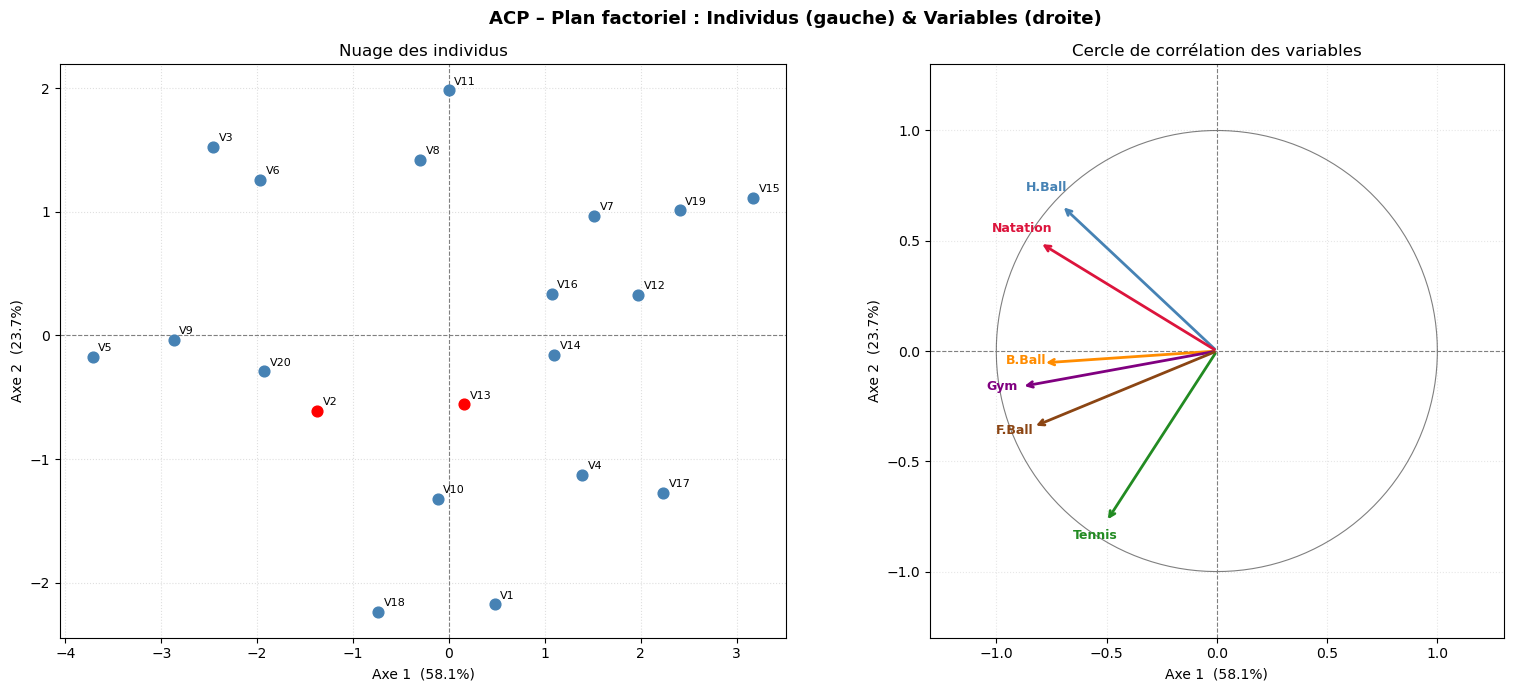

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle("ACP – Plan factoriel : Individus (gauche) & Variables (droite)",
             fontsize=13, fontweight="bold")

# ─ Sous-figure gauche : individus ─
ax = axes[0]
ax.axhline(0, color="gray", lw=0.8, ls="--")
ax.axvline(0, color="gray", lw=0.8, ls="--")
for i, ville in enumerate(noms_villes):
    couleur = "red" if cos2_plan[i] < 0.5 else "steelblue"
    ax.scatter(C[i, 0], C[i, 1], color=couleur, s=60, zorder=5)
    ax.annotate(ville, (C[i, 0], C[i, 1]), xytext=(4, 4),
                textcoords="offset points", fontsize=8)
ax.set_xlabel(f"Axe 1  ({taux[0]:.1f}%)")
ax.set_ylabel(f"Axe 2  ({taux[1]:.1f}%)")
ax.set_title("Nuage des individus")
ax.grid(ls=":", alpha=0.4)

# ─ Sous-figure droite : variables (cercle de corrélation) ─
ax2 = axes[1]
theta = np.linspace(0, 2*np.pi, 300)
ax2.plot(np.cos(theta), np.sin(theta), "k-", lw=0.8, alpha=0.5)
ax2.axhline(0, color="gray", lw=0.8, ls="--")
ax2.axvline(0, color="gray", lw=0.8, ls="--")
for j, sport in enumerate(noms_sports):
    x, y = coord_var[j, 0], coord_var[j, 1]
    ax2.annotate("", xy=(x, y), xytext=(0, 0),
                 arrowprops=dict(arrowstyle="->", color=couleurs_sports[j], lw=2))
    ax2.text(x * 1.10, y * 1.10, sport, fontsize=9,
             color=couleurs_sports[j], ha="center", fontweight="bold")
ax2.set_xlim(-1.3, 1.3)
ax2.set_ylim(-1.3, 1.3)
ax2.set_aspect("equal")
ax2.set_xlabel(f"Axe 1  ({taux[0]:.1f}%)")
ax2.set_ylabel(f"Axe 2  ({taux[1]:.1f}%)")
ax2.set_title("Cercle de corrélation des variables")
ax2.grid(ls=":", alpha=0.3)

plt.tight_layout()
plt.show()

### 8 – BIPLOT — Carte d'analyse des correspondances


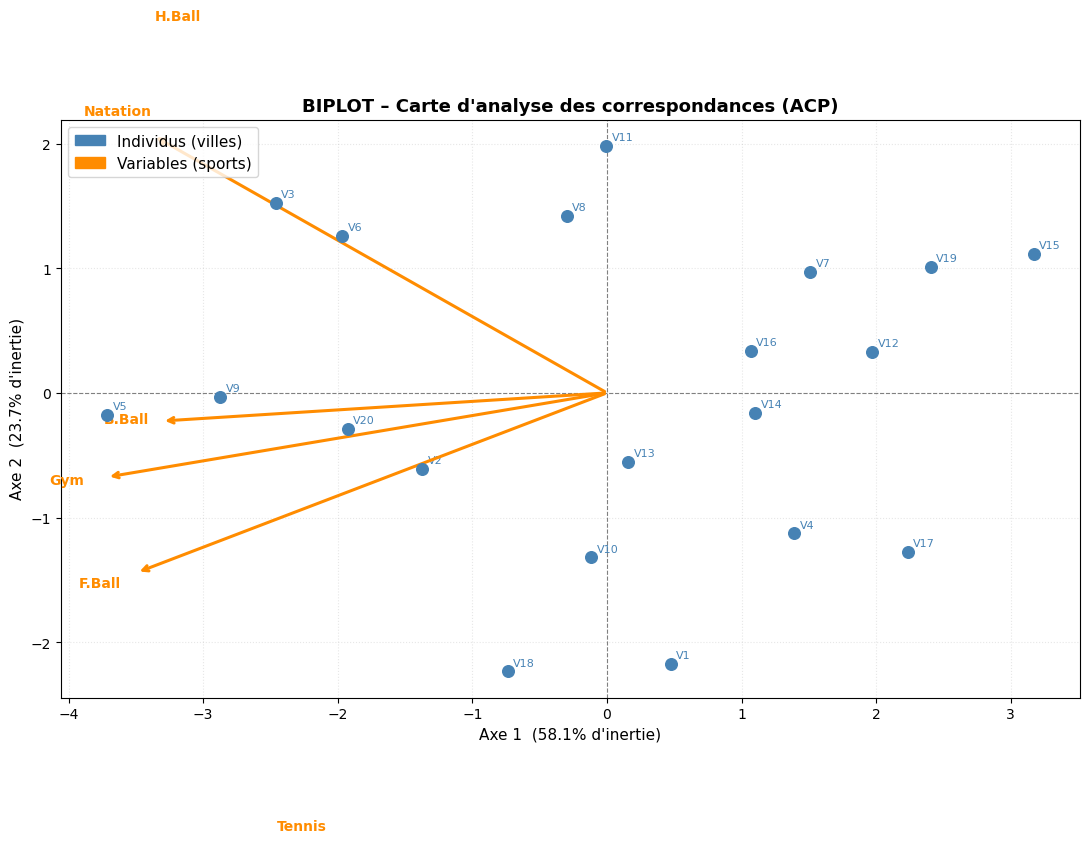

Interprétation du biplot :
  → Une ville PROCHE d'une flèche de variable : fort taux de pratique de ce sport.
  → Flèches dans la même direction : sports corrélés positivement.
  → Flèches opposées : corrélation négative entre sports.
  → Ville à DROITE du plan : profil sportif élevé global (axe 1 +).
  → Ville à GAUCHE du plan : profil sportif faible global (axe 1 −).


In [26]:
fig, ax = plt.subplots(figsize=(11, 9))
ax.axhline(0, color="gray", lw=0.8, ls="--")
ax.axvline(0, color="gray", lw=0.8, ls="--")

# ─ Individus (BLEU) ─
for i, ville in enumerate(noms_villes):
    ax.scatter(C[i, 0], C[i, 1], color="steelblue", s=70, zorder=5)
    ax.annotate(ville, (C[i, 0], C[i, 1]), xytext=(4, 4),
                textcoords="offset points", fontsize=8, color="steelblue")

# ─ Variables (ORANGE) —
scale = np.max(np.abs(C[:, :2])) / np.max(np.abs(coord_var[:, :2]))
for j, sport in enumerate(noms_sports):
    x = coord_var[j, 0] * scale
    y = coord_var[j, 1] * scale
    ax.annotate("", xy=(x, y), xytext=(0, 0),
                arrowprops=dict(arrowstyle="->", color="darkorange", lw=2.2))
    ax.text(x * 1.08, y * 1.08, sport, fontsize=10,
            color="darkorange", ha="center", fontweight="bold")


p1 = mpatches.Patch(color="steelblue",  label="Individus (villes)")
p2 = mpatches.Patch(color="darkorange", label="Variables (sports)")
ax.legend(handles=[p1, p2], fontsize=11, loc="upper left")

ax.set_xlabel(f"Axe 1  ({taux[0]:.1f}% d'inertie)", fontsize=11)
ax.set_ylabel(f"Axe 2  ({taux[1]:.1f}% d'inertie)", fontsize=11)
ax.set_title("BIPLOT – Carte d'analyse des correspondances (ACP)",
             fontsize=13, fontweight="bold")
ax.grid(ls=":", alpha=0.3)
plt.tight_layout()
plt.show()

print("Interprétation du biplot :")
print("  → Une ville PROCHE d'une flèche de variable : fort taux de pratique de ce sport.")
print("  → Flèches dans la même direction : sports corrélés positivement.")
print("  → Flèches opposées : corrélation négative entre sports.")
print("  → Ville à DROITE du plan : profil sportif élevé global (axe 1 +).")
print("  → Ville à GAUCHE du plan : profil sportif faible global (axe 1 −).")